In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# -----------------------------------------------
# Load shared log-return and event-date input files
# -----------------------------------------------

DATA_DIR = Path("../Data")
LOG_RETURNS_FILE = DATA_DIR / "crypto_and_crix_log_returns.csv"
EVENT_DATES_FILE = DATA_DIR / "event_dates.csv"
MARKET_MODEL_COLUMNS = ["CRIX", "ETH"]

event_dates = pd.read_csv(EVENT_DATES_FILE, parse_dates=["event_date"])
EVENT_DATES = event_dates["event_date"].tolist()

log_returns = pd.read_csv(
    LOG_RETURNS_FILE,
    index_col="Date",
    parse_dates=["Date"],
)

missing_columns = set(MARKET_MODEL_COLUMNS).difference(log_returns.columns)
if missing_columns:
    raise ValueError(f"Missing required return columns: {sorted(missing_columns)}")

market_model_returns = log_returns[MARKET_MODEL_COLUMNS].copy()
market_model_returns.index = pd.to_datetime(market_model_returns.index)


In [2]:
import statsmodels.api as sm

def run_market_model(
    return_data: pd.DataFrame,
    market_column: str = "CRIX",
    asset_column: str = "ETH",
):
    """
    Fit a single-factor market model (ETH return regressed on CRIX return),
    clean NaN/inf values first, and compute abnormal returns.
    """
    df = return_data.copy()

    if df[[market_column, asset_column]].isnull().values.any():
        print("NaN values found. Dropping NaNs.")
        df = df.dropna(subset=[market_column, asset_column])

    if np.isinf(df[[market_column, asset_column]].values).any():
        print("Infinite values found. Dropping infinities.")
        df = df[np.isfinite(df[market_column]) & np.isfinite(df[asset_column])]

    if df[market_column].nunique() == 1 or df[asset_column].nunique() == 1:
        raise ValueError("One of the columns has constant values, which will cause issues in regression.")

    X = sm.add_constant(df[market_column].values.reshape(-1, 1))
    y = df[asset_column].values.reshape(-1, 1)
    results = sm.OLS(y, X).fit()
    alpha, beta = results.params
    print("Alpha, Beta:", alpha, beta)

    df["expected_return"] = alpha + beta * df[market_column]
    df["abnormal_return"] = df[asset_column] - df["expected_return"]
    return df, alpha, beta, results


def plot_eth_and_abnormal_return(df, event_dates, save_path=None):
    """
    Two-panel chart: raw ETH log return on top, cumulative-style
    normalized abnormal return on bottom, with event date markers.
    """
    plt.rcParams['font.family'] = 'serif'

    fig, axes = plt.subplots(2, 1, figsize=(20, 12), sharex=True, gridspec_kw={'hspace': 0.05})

    axes[0].plot(df.index, df["ETH"], color='black', linewidth=2)
    axes[0].set_ylabel('Log return', fontsize=16)

    ar_ratio = np.exp(df["abnormal_return"]) / np.exp(df["abnormal_return"].min())
    axes[1].plot(df.index, ar_ratio, color='blue', linewidth=2)
    axes[1].set_ylabel("Normalized abnormal return", fontsize=16)

    for ax in axes:
        for d in event_dates:
            ax.axvline(pd.to_datetime(d), color='#7f7f7f', linestyle=':', linewidth=0.5)
        ax.set_facecolor('none')
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('black')
            spine.set_linewidth(1)
        ax.tick_params(axis='both', labelsize=14)

    axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

    fig.patch.set_alpha(0)
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=200, transparent=True)

    plt.show()
    return fig

Alpha, Beta: 0.0004796470152880308 0.44525528694219435


C:\Users\StefanGaman\AppData\Local\Temp\ipykernel_22448\1074721519.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


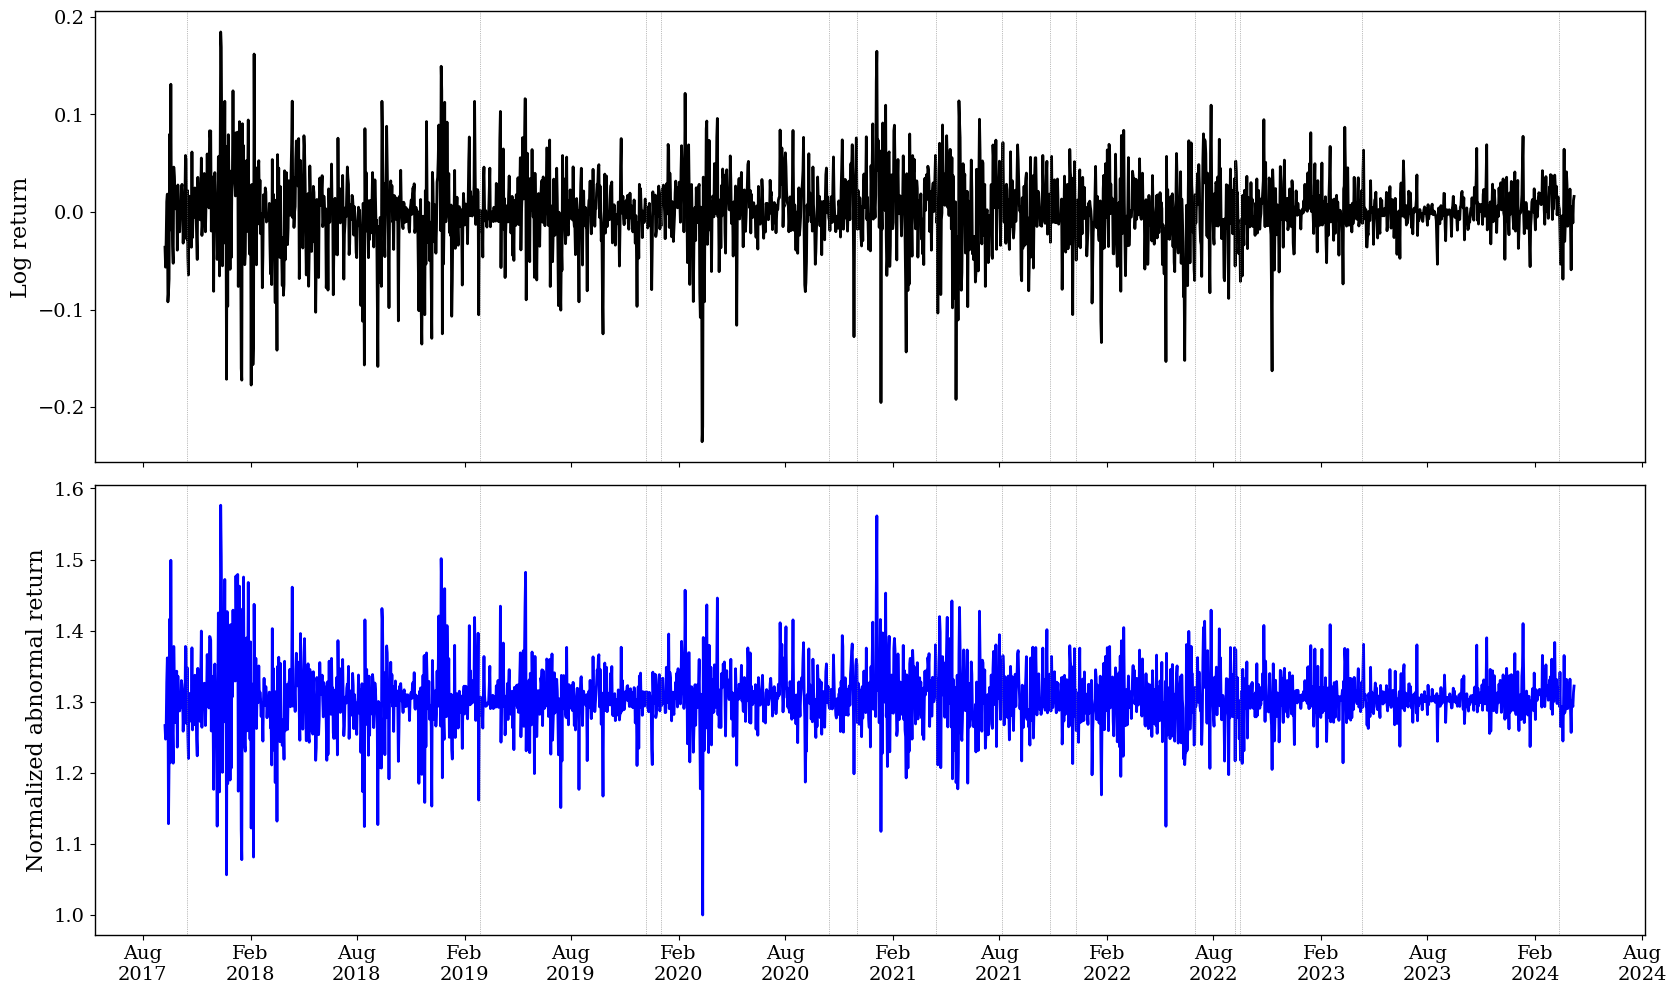

In [3]:
market_model_results, alpha, beta, ols_results = run_market_model(market_model_returns)
fig = plot_eth_and_abnormal_return(
    market_model_results, EVENT_DATES, save_path="indicator_ts.png"
)

output_path = DATA_DIR / "market_model_results.csv"
market_model_results.to_csv(output_path)